In [1]:
import pathlib
import cv2
import numpy as np
import pandas as pd
import os
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout, Conv2D, MaxPooling2D
from tensorflow.keras.optimizers import Adam
from keras import models, layers
from tensorflow.keras.models import Model
from tensorflow.keras.metrics import Precision, Recall, AUC

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50

from tensorflow.keras import optimizers

from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report

import random

np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

c:\Users\Acer\anaconda3\Lib\site-packages\h5py\__init__.py:36: UserWarning: h5py is running against HDF5 1.14.5 when it was built against 1.14.6, this may cause problems
  _warn(("h5py is running against HDF5 {0} when it was built against {1}, "


## 3) ResNet50

In [2]:
from tensorflow.keras.applications.resnet50 import preprocess_input

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=15,
    zoom_range=0.1,
    horizontal_flip=True,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,

    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    "Chest-Xray-2/chest_xray/train",
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    subset='training',
    shuffle=True
)

Found 4187 images belonging to 2 classes.


In [3]:
val_generator = train_datagen.flow_from_directory(
    "Chest-Xray-2/chest_xray/train",
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    subset='validation',
    shuffle=True
)

Found 1045 images belonging to 2 classes.


In [4]:
test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

test_generator = test_datagen.flow_from_directory(
    "Chest-Xray-2/chest_xray/test",
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

Found 624 images belonging to 2 classes.


In [5]:
print(train_generator.class_indices)

{'NORMAL': 0, 'PNEUMONIA': 1}


In [6]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)

class_weights = dict(enumerate(class_weights))

print(class_weights)

{0: np.float64(1.938425925925926), 1: np.float64(0.6738010943031864)}


In [7]:
checkpointer = ModelCheckpoint(
    filepath='ResNet50_best_model.keras',
    monitor='val_loss',
    save_best_only=True,
    mode='min',
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=6,
    restore_best_weights=True,
    mode='min',
    verbose=1
)

lr_reduce = ReduceLROnPlateau(
    monitor='val_loss',
    patience=3, 
    factor=0.2,
    min_lr=1e-6,
    mode='min',
    verbose=1
)

In [8]:
base_model = ResNet50(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

In [9]:
inputs = base_model.input

x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)

x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.4)(x)

x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.3)(x)

outputs = layers.Dense(1, activation='sigmoid')(x)

resnet_model = Model(inputs, outputs)

In [10]:
resnet_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 24,153,473 (92.14 MB)

 Trainable params: 561,665 (2.14 MB)

 Non-trainable params: 23,591,808 (90.00 MB)

In [11]:
resnet_model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        Precision(name='precision'),
        Recall(name='recall'),
        AUC(name='auc') 
    ]
)

In [12]:
resnet_history = resnet_model.fit(
    train_generator,
    epochs=20,
    validation_data=val_generator,
    callbacks=[checkpointer, early_stop, lr_reduce],
    class_weight=class_weights,
    verbose=1
)

Epoch 1/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7539 - auc: 0.8756 - loss: 0.4320 - precision: 0.9376 - recall: 0.7091
Epoch 1: val_loss improved from None to 0.25868, saving model to ResNet50_best_model.keras

Epoch 1: finished saving model to ResNet50_best_model.keras
131/131 ━━━━━━━━━━━━━━━━━━━━ 373s 3s/step - accuracy: 0.8481 - auc: 0.9486 - loss: 0.2948 - precision: 0.9675 - recall: 0.8230 - val_accuracy: 0.8938 - val_auc: 0.9886 - val_loss: 0.2587 - val_precision: 0.9926 - val_recall: 0.8634 - learning_rate: 1.0000e-04
Epoch 2/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9207 - auc: 0.9779 - loss: 0.1852 - precision: 0.9721 - recall: 0.9218
Epoch 2: val_loss improved from 0.25868 to 0.17193, saving model to ResNet50_best_model.keras

Epoch 2: finished saving model to ResNet50_best_model.keras
131/131 ━━━━━━━━━━━━━━━━━━━━ 252s 2s/step - accuracy: 0.9274 - auc: 0.9809 - loss: 0.1743 - precision: 0.9759 - recall: 0.9250 - val_accuracy: 0.9301 - val_auc: 

### Fine Tune

In [13]:
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

In [14]:
resnet_model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        Precision(name='precision'),
        Recall(name='recall'),
        AUC(name='auc')
    ]
)

In [15]:
fine_tune_history = resnet_model.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator,
    callbacks=[checkpointer, early_stop, lr_reduce],
    class_weight=class_weights,
    verbose=1
)

Epoch 1/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9507 - auc: 0.9862 - loss: 0.1463 - precision: 0.9783 - recall: 0.9550
Epoch 1: val_loss did not improve from 0.07215
131/131 ━━━━━━━━━━━━━━━━━━━━ 306s 2s/step - accuracy: 0.9520 - auc: 0.9887 - loss: 0.1299 - precision: 0.9840 - recall: 0.9508 - val_accuracy: 0.9636 - val_auc: 0.9951 - val_loss: 0.0969 - val_precision: 0.9960 - val_recall: 0.9549 - learning_rate: 1.0000e-05
Epoch 2/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9529 - auc: 0.9927 - loss: 0.1034 - precision: 0.9885 - recall: 0.9482
Epoch 2: val_loss did not improve from 0.07215
131/131 ━━━━━━━━━━━━━━━━━━━━ 293s 2s/step - accuracy: 0.9584 - auc: 0.9928 - loss: 0.1005 - precision: 0.9887 - recall: 0.9549 - val_accuracy: 0.9646 - val_auc: 0.9964 - val_loss: 0.0852 - val_precision: 0.9960 - val_recall: 0.9562 - learning_rate: 1.0000e-05
Epoch 3/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9632 - auc: 0.9927 - loss: 0.0964 - precision: 0.

Fine-tuning did not improve performance, indicating that the pretrained ResNet50 features were already sufficient for this dataset.

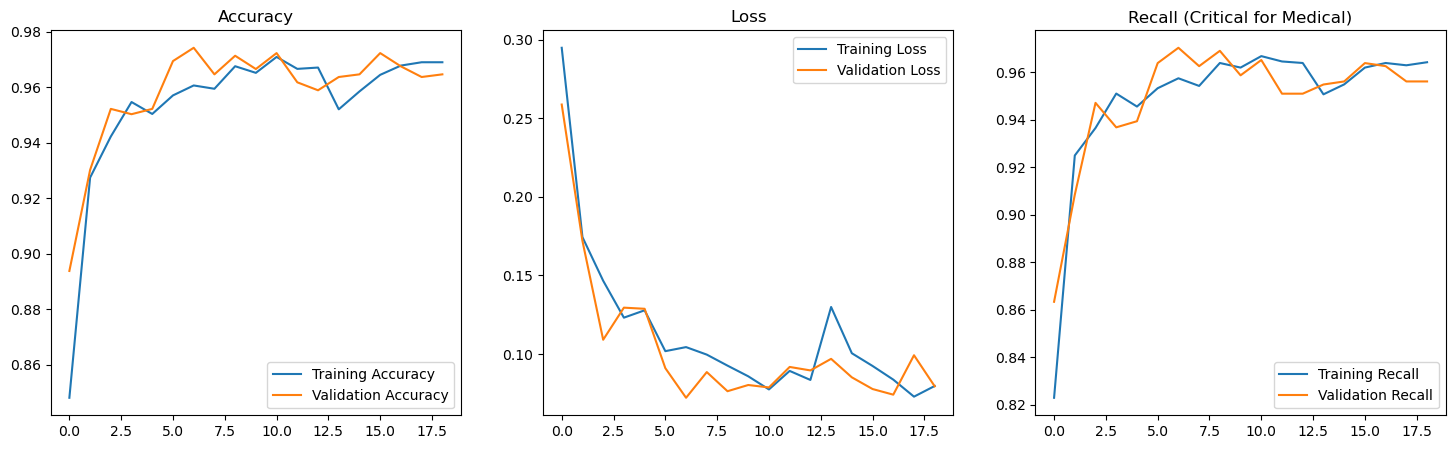

In [16]:
acc = resnet_history.history['accuracy'] + fine_tune_history.history['accuracy']
val_acc = resnet_history.history['val_accuracy'] + fine_tune_history.history['val_accuracy']

loss = resnet_history.history['loss'] + fine_tune_history.history['loss']
val_loss = resnet_history.history['val_loss'] + fine_tune_history.history['val_loss']

recall = resnet_history.history['recall'] + fine_tune_history.history['recall']
val_recall = resnet_history.history['val_recall'] + fine_tune_history.history['val_recall']

epochs_range = range(len(acc))

plt.figure(figsize=(18, 5))

# Accuracy
plt.subplot(1, 3, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend()
plt.title('Accuracy')

# Loss
plt.subplot(1, 3, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend()
plt.title('Loss')

# Recall
plt.subplot(1, 3, 3)
plt.plot(epochs_range, recall, label='Training Recall')
plt.plot(epochs_range, val_recall, label='Validation Recall')
plt.legend()
plt.title('Recall (Critical for Medical)')

plt.show()

>The model achieves stable convergence with high validation accuracy (~97%) and high recall (~96–97%), indicating strong generalization and reliable pneumonia detection without overfitting.

In [17]:
results = resnet_model.evaluate(test_generator)

print("Test Loss:", results[0])
print("Test Accuracy:", results[1])
print("Test Precision:", results[2])
print("Test Recall:", results[3])
print("Test AUC:", results[4])

20/20 ━━━━━━━━━━━━━━━━━━━━ 27s 1s/step - accuracy: 0.9087 - auc: 0.9571 - loss: 0.2796 - precision: 0.9173 - recall: 0.9385
Test Loss: 0.27956047654151917
Test Accuracy: 0.9086538553237915
Test Precision: 0.9172932505607605
Test Recall: 0.9384615421295166
Test AUC: 0.9571170210838318


>ResNet50 provides a balanced performance with high precision and recall, along with strong AUC, making it a reliable model for pneumonia classification.

In [18]:
y_pred_prob = resnet_model.predict(test_generator)

20/20 ━━━━━━━━━━━━━━━━━━━━ 30s 1s/step


In [19]:
y_pred = (y_pred_prob > 0.5).astype("int32").flatten()

In [20]:
y_true = test_generator.classes

In [21]:
print(classification_report(
    y_true,
    y_pred,
    target_names=['NORMAL', 'PNEUMONIA'],
    zero_division=0
))

              precision    recall  f1-score   support

      NORMAL       0.89      0.86      0.88       234
   PNEUMONIA       0.92      0.94      0.93       390

    accuracy                           0.91       624
   macro avg       0.91      0.90      0.90       624
weighted avg       0.91      0.91      0.91       624



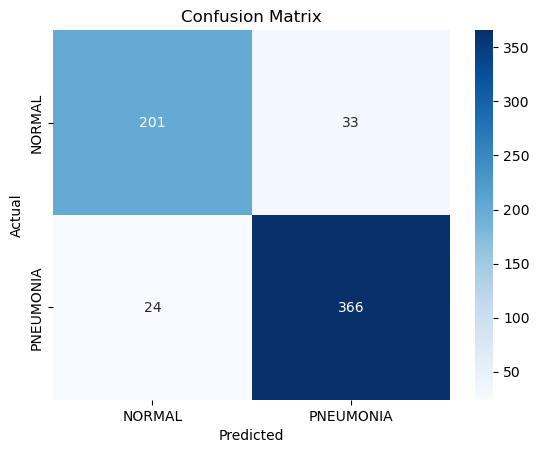

In [22]:
cm = confusion_matrix(y_true, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['NORMAL', 'PNEUMONIA'],
            yticklabels=['NORMAL', 'PNEUMONIA'])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

MobileNetV2 achieved higher recall (~97%), making it more suitable for medical applications where minimizing false negatives is critical. In contrast, ResNet50 provided a more balanced performance with higher precision and AUC, reducing false positives while maintaining strong detection capability.

>For a medical screening system, I would choose MobileNetV2 because it achieves higher recall and minimizes missed pneumonia cases. However, for a clinical decision-support system where precision is also important, ResNet50 would be preferred due to its balanced performance and higher AUC.

### Grad-CAM visualization

In [28]:
last_conv_layer_name = "conv5_block3_out"

In [ ]:
def get_img_array(img_path, size=(224, 224)):
    img = tf.keras.preprocessing.image.load_img(img_path, target_size=size)
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    return preprocess_input(img_array)

In [ ]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name):

    grad_model = tf.keras.models.Model(
        inputs=model.input,
        outputs=[
            model.get_layer(last_conv_layer_name).output,
            model.output
        ]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        loss = predictions[:, 0]

    grads = tape.gradient(loss, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)

    return heatmap.numpy()

In [ ]:
def display_gradcam(img_path, heatmap, alpha=0.4):

    img = cv2.imread(img_path)
    img = cv2.resize(img, (224, 224))

    heatmap = cv2.resize(heatmap, (224, 224))
    heatmap = np.uint8(255 * heatmap)

    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    superimposed_img = heatmap * alpha + img

    plt.figure(figsize=(6,6))
    plt.imshow(cv2.cvtColor(superimposed_img.astype("uint8"), cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.title("Grad-CAM (ResNet50)")
    plt.show()

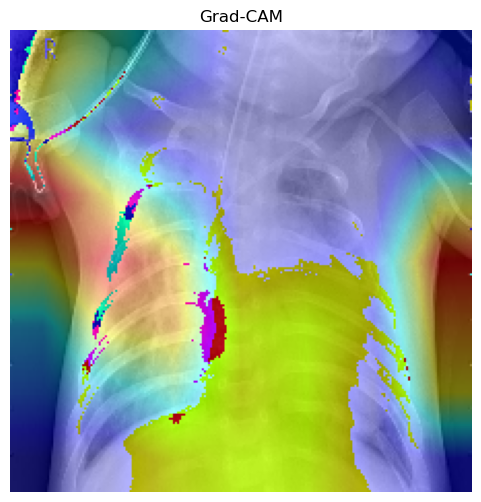

In [33]:
img_path1 = "Chest-Xray-2/chest_xray/test/PNEUMONIA/person1_virus_6.jpeg"

img_array = get_img_array(img_path1)

heatmap = make_gradcam_heatmap(
    img_array,
    resnet_model,
    last_conv_layer_name="conv5_block3_out"
)

display_gradcam(img_path1, heatmap)

* Strong activation in:
  - Left lung region (mid–lower zone)
  - Some attention near central chest
* Activation is:
  - More localized and sharper
  - Less spread compared to MobileNet

ResNet is focusing on a specific suspicious region instead of scanning broadly

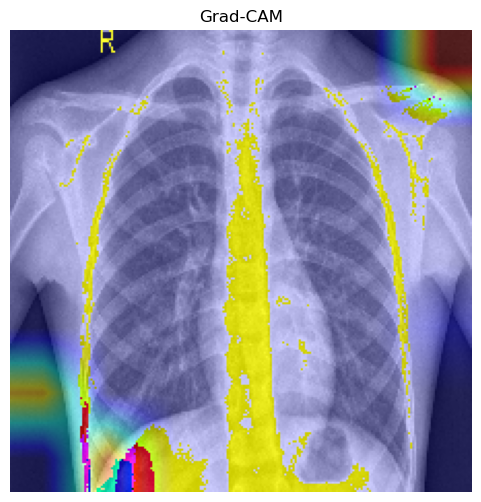

In [34]:
img_path2 = "Chest-Xray-2/chest_xray/test/NORMAL/IM-0001-0001.jpeg"

img_array = get_img_array(img_path2)

heatmap = make_gradcam_heatmap(
    img_array,
    resnet_model,
    last_conv_layer_name="conv5_block3_out"
)

display_gradcam(img_path2, heatmap)

* No strong red hotspots inside lungs 
* Activation is:
  - Mostly diffuse
  - Slight attention on:
    + Spine (center vertical region)
    + Edges / borders

Model is NOT detecting abnormal regions inside lungs

---

>Grad-CAM for normal images shows no strong activation in lung regions, confirming that the model does not detect pathological features.

**How does Grad-CAM behave for normal cases?**

For normal chest X-rays, Grad-CAM shows diffuse attention without strong activation in lung regions, indicating that the model does not detect abnormal features and correctly identifies healthy cases.

| Metric               | Custom CNN | MobileNetV2         | ResNet50              |
| -------------------- | ---------- | ------------------- | --------------------- |
| Accuracy             | ~87–88%    | ~86.9%              | **90.9%** ✅           |
| Precision            | ~91.3%     | ~84.2%              | **91.7%** 🔥          |
| Recall (Critical)    | ~89.2%     | **97.1%** 🔥        | ~93.8%                |
| AUC                  | ~0.90–0.92 | ~0.94–0.95          | **0.957** 🔥          |
| False Negatives (FN) | Moderate   | **Very Low (11)** ✅ | Low (24)              |
| False Positives (FP) | Moderate   | High (71)           | **Low (33)** ✅        |
| Model Complexity     | Low        | Low (Efficient)     | High                  |
| Training Time        | Fast       | Fast                | Slow                  |
| Generalization       | Good       | Very Good           | **Excellent**         |
| Overfitting Risk     | Medium     | Low                 | Medium                |
| Grad-CAM Quality     | Basic      | Good (broad)        | **Best (focused)** 🔥 |


## 5) Attention Mechanisms (CBAM)

ResNet50 already showed balanced performance and correct localization. Applying CBAM helps refine feature attention, improving precision and reducing false positives, which aligns with findings from recent research.

In [11]:
from tensorflow.keras import layers

def cbam_block(input_feature, ratio=8):

    channel = input_feature.shape[-1]

    # ----- Channel Attention -----
    shared_dense_one = layers.Dense(channel // ratio, activation='relu')
    shared_dense_two = layers.Dense(channel)

    avg_pool = layers.GlobalAveragePooling2D()(input_feature)
    avg_pool = layers.Reshape((1,1,channel))(avg_pool)
    avg_pool = shared_dense_one(avg_pool)
    avg_pool = shared_dense_two(avg_pool)

    max_pool = layers.GlobalMaxPooling2D()(input_feature)
    max_pool = layers.Reshape((1,1,channel))(max_pool)
    max_pool = shared_dense_one(max_pool)
    max_pool = shared_dense_two(max_pool)

    channel_attention = layers.Add()([avg_pool, max_pool])
    channel_attention = layers.Activation('sigmoid')(channel_attention)

    channel_refined = layers.Multiply()([input_feature, channel_attention])

    # ----- Spatial Attention -----

    avg_pool = layers.Lambda(lambda x: tf.reduce_mean(x, axis=-1, keepdims=True))(channel_refined)
    max_pool = layers.Lambda(lambda x: tf.reduce_max(x, axis=-1, keepdims=True))(channel_refined)

    concat = layers.Concatenate(axis=-1)([avg_pool, max_pool])

    spatial_attention = layers.Conv2D(
        filters=1,
        kernel_size=7,
        padding='same',
        activation='sigmoid'
    )(concat)

    refined_feature = layers.Multiply()([channel_refined, spatial_attention])

    return refined_feature

In [8]:
checkpointer = ModelCheckpoint(
    filepath='ResNet50_CBAM_best_model.keras',
    monitor='val_loss',
    save_best_only=True,
    mode='min',
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=7,
    restore_best_weights=True,
    mode='min',
    verbose=1
)

lr_reduce = ReduceLROnPlateau(
    monitor='val_loss',
    patience=3,
    factor=0.2,
    min_lr=1e-6,
    mode='min',
    verbose=1
)

In [9]:
base_model = ResNet50(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False 

In [12]:
inputs = base_model.input
x = base_model.output

x = cbam_block(x)

x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)

x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.4)(x)

x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.3)(x)

outputs = layers.Dense(1, activation='sigmoid')(x)

resnet_cbam_model = Model(inputs, outputs)

In [13]:
resnet_cbam_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 25,204,452 (96.15 MB)

 Trainable params: 1,612,644 (6.15 MB)

 Non-trainable params: 23,591,808 (90.00 MB)

In [14]:
resnet_cbam_model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        Precision(name='precision'),
        Recall(name='recall'),
        AUC(name='auc')
    ]
)

In [15]:
resnet_cbam_history = resnet_cbam_model.fit(
    train_generator,
    epochs=40,
    validation_data=val_generator,
    callbacks=[checkpointer, early_stop, lr_reduce],
    class_weight=class_weights,
    verbose=1
)

Epoch 1/40
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7248 - auc: 0.8483 - loss: 0.4603 - precision: 0.9095 - recall: 0.6885
Epoch 1: val_loss improved from None to 0.38496, saving model to ResNet50_CBAM_best_model.keras

Epoch 1: finished saving model to ResNet50_CBAM_best_model.keras
131/131 ━━━━━━━━━━━━━━━━━━━━ 337s 3s/step - accuracy: 0.8354 - auc: 0.9409 - loss: 0.3211 - precision: 0.9583 - recall: 0.8136 - val_accuracy: 0.9464 - val_auc: 0.9881 - val_loss: 0.3850 - val_precision: 0.9800 - val_recall: 0.9472 - learning_rate: 1.0000e-04
Epoch 2/40
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9241 - auc: 0.9727 - loss: 0.1984 - precision: 0.9773 - recall: 0.9198
Epoch 2: val_loss improved from 0.38496 to 0.21814, saving model to ResNet50_CBAM_best_model.keras

Epoch 2: finished saving model to ResNet50_CBAM_best_model.keras
131/131 ━━━━━━━━━━━━━━━━━━━━ 246s 2s/step - accuracy: 0.9353 - auc: 0.9809 - loss: 0.1699 - precision: 0.9820 - recall: 0.9298 - val_accuracy

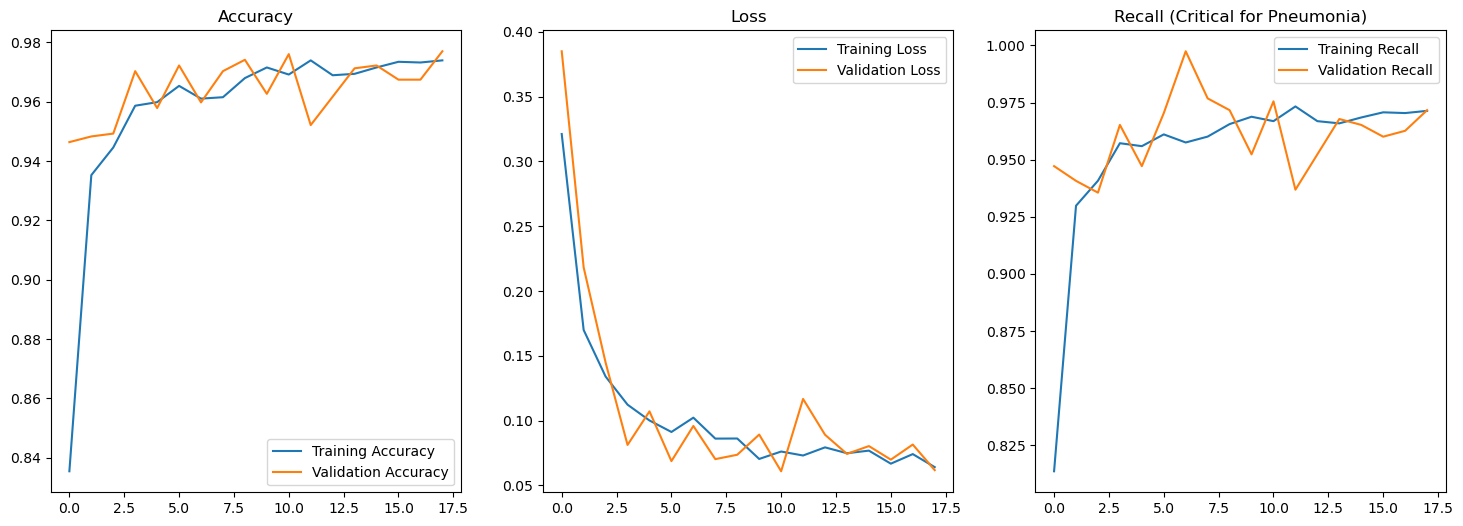

In [16]:
acc = resnet_cbam_history.history['accuracy']
val_acc = resnet_cbam_history.history['val_accuracy']

loss = resnet_cbam_history.history['loss']
val_loss = resnet_cbam_history.history['val_loss']

recall = resnet_cbam_history.history['recall']
val_recall = resnet_cbam_history.history['val_recall']

precision = resnet_cbam_history.history['precision']
val_precision = resnet_cbam_history.history['val_precision']

epochs_range = range(len(acc))

import matplotlib.pyplot as plt

plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend()
plt.title('Accuracy')

plt.subplot(1, 3, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend()
plt.title('Loss')

plt.subplot(1, 3, 3)
plt.plot(epochs_range, recall, label='Training Recall')
plt.plot(epochs_range, val_recall, label='Validation Recall')
plt.legend()
plt.title('Recall (Critical for Pneumonia)')

plt.show()

The CBAM-enhanced ResNet50 model demonstrates stable training with minimal overfitting, achieving high accuracy and consistently strong recall, making it highly suitable for medical diagnosis.

In [17]:
results = resnet_cbam_model.evaluate(test_generator)

print("Test Loss:", results[0])
print("Test Accuracy:", results[1])
print("Test Precision:", results[2])
print("Test Recall:", results[3])
print("Test AUC:", results[4])

20/20 ━━━━━━━━━━━━━━━━━━━━ 29s 1s/step - accuracy: 0.8942 - auc: 0.9572 - loss: 0.2995 - precision: 0.8894 - recall: 0.9487
Test Loss: 0.29950112104415894
Test Accuracy: 0.8942307829856873
Test Precision: 0.8894230723381042
Test Recall: 0.9487179517745972
Test AUC: 0.9571554064750671


CBAM improved recall and AUC by enhancing feature attention, making the model more sensitive to pneumonia regions. Although accuracy slightly decreased, the improved recall makes it more suitable for medical applications.

In [18]:
y_pred_prob = resnet_cbam_model.predict(test_generator)

20/20 ━━━━━━━━━━━━━━━━━━━━ 26s 1s/step


In [19]:
y_pred = (y_pred_prob > 0.5).astype("int32").flatten()

In [20]:
y_true = test_generator.classes

In [21]:
print(classification_report(
    y_true,
    y_pred,
    target_names=['NORMAL', 'PNEUMONIA'],
    zero_division=0
))

              precision    recall  f1-score   support

      NORMAL       0.90      0.80      0.85       234
   PNEUMONIA       0.89      0.95      0.92       390

    accuracy                           0.89       624
   macro avg       0.90      0.88      0.88       624
weighted avg       0.89      0.89      0.89       624



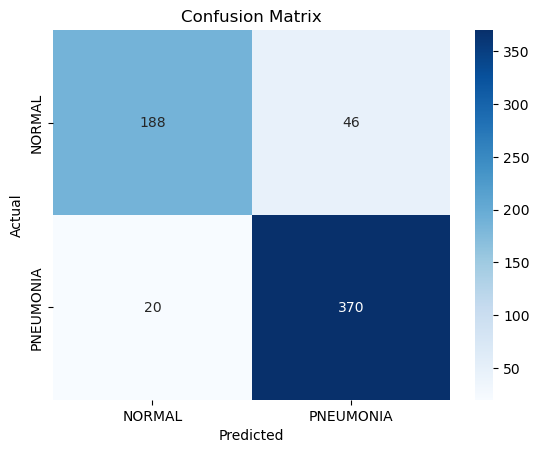

In [22]:
cm = confusion_matrix(y_true, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['NORMAL', 'PNEUMONIA'],
            yticklabels=['NORMAL', 'PNEUMONIA'])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

The model demonstrates high sensitivity by correctly identifying most pneumonia cases while maintaining acceptable false positives, making it suitable for medical screening tasks.

ResNet50 with CBAM provides the most clinically reliable performance by minimizing missed pneumonia cases, which is critical for patient safety.

### Grad-CAM visualization

In [23]:
last_conv_layer_name = "conv5_block3_out"

In [24]:
def get_img_array(img_path, size=(224, 224)):
    img = tf.keras.preprocessing.image.load_img(img_path, target_size=size)
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    return preprocess_input(img_array)

In [25]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name):

    grad_model = tf.keras.models.Model(
        inputs=model.input,
        outputs=[
            model.get_layer(last_conv_layer_name).output,
            model.output
        ]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        loss = predictions[:, 0]

    grads = tape.gradient(loss, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)

    return heatmap.numpy()

In [26]:
def display_gradcam(img_path, heatmap, alpha=0.4):

    img = cv2.imread(img_path)
    img = cv2.resize(img, (224, 224))

    heatmap = cv2.resize(heatmap, (224, 224))
    heatmap = np.uint8(255 * heatmap)

    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    superimposed_img = heatmap * alpha + img

    plt.figure(figsize=(6,6))
    plt.imshow(cv2.cvtColor(superimposed_img.astype("uint8"), cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.title("Grad-CAM (ResNet50 with CBAM)")
    plt.show()

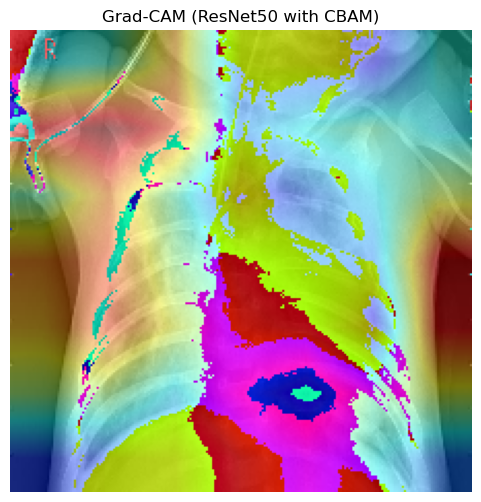

In [27]:
img_path1 = "Chest-Xray-2/chest_xray/test/PNEUMONIA/person1_virus_6.jpeg"

img_array = get_img_array(img_path1)

heatmap = make_gradcam_heatmap(
    img_array,
    resnet_cbam_model,
    last_conv_layer_name="conv5_block3_out"
)

display_gradcam(img_path1, heatmap)

The heatmap shows that the model focuses on clinically relevant lung regions, particularly areas with possible infection, indicating that the model has learned meaningful features for pneumonia detection.

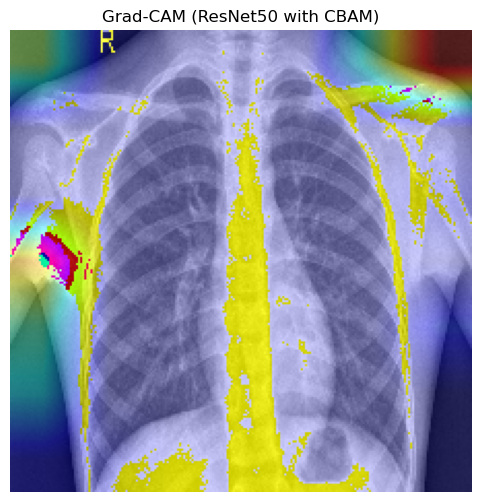

In [28]:
img_path2 = "Chest-Xray-2/chest_xray/test/NORMAL/IM-0001-0001.jpeg"

img_array = get_img_array(img_path2)

heatmap = make_gradcam_heatmap(
    img_array,
    resnet_cbam_model,
    last_conv_layer_name="conv5_block3_out"
)

display_gradcam(img_path2, heatmap)

The model does not focus on any specific lung region, indicating absence of abnormal patterns, which confirms correct classification of a normal X-ray.

---

| Model               | Accuracy    | Precision | Recall      | F1-Score | AUC       | Key Strength                            | Weakness                |
| ------------------- | ----------- | --------- | ----------- | -------- | --------- | --------------------------------------- | ----------------------- |
| **Custom CNN**      | 0.88        | **0.91**  | 0.89        | 0.88     | —         | Balanced performance                    | Lower generalization    |
| **MobileNetV2**     | 0.87        | 0.84      | **🔥 0.97** | 0.86     | —         | Highest recall (detects most pneumonia) | High false positives    |
| **ResNet50**        | **🔥 0.91** | **0.92**  | 0.94        | **0.91** | 0.957     | Best overall performance                | Slightly complex        |
| **ResNet50 + CBAM** | 0.89        | 0.89      | **🔥 0.95** | 0.89     | **0.957** | Best medical reliability                | Slight drop in accuracy |


>Among all models, ResNet50 achieved the highest overall performance, while the CBAM-enhanced ResNet50 demonstrated superior recall and interpretability, making it more suitable for medical diagnosis.